In [1]:
from google.colab import files
uploaded = files.upload()


Saving archive (4).zip to archive (4).zip


Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')
Model Accuracy: 0.9473684210526315


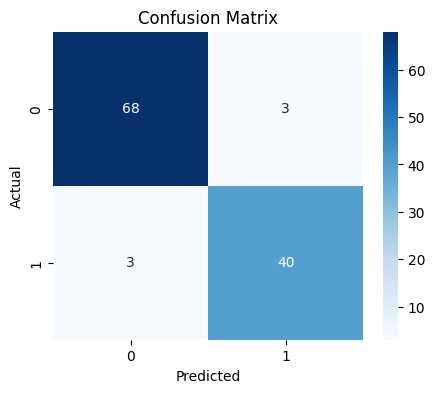

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [3]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import io

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Load Dataset
# The original URL is no longer valid, using the uploaded file instead.
# url = "https://raw.githubusercontent.com/uciml/breast-cancer-wisconsin-data/master/data.csv"
# df = pd.read_csv(url)

# Extract data.csv from the uploaded zip file
with zipfile.ZipFile(io.BytesIO(uploaded['archive (4).zip']), 'r') as zf:
    with zf.open('data.csv') as f:
        df = pd.read_csv(f)

# Step 3: Display Columns
print(df.columns)

# Step 4: Drop unnecessary columns
df = df.drop(['id','Unnamed: 32'], axis=1)

# Step 5: Separate features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Encode target variable
y = y.map({'M':1,'B':0})

# Step 6: Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 7: Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 8: Train KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Step 9: Prediction
y_pred = knn.predict(X_test)

# Step 10: Accuracy
print("Model Accuracy:", accuracy_score(y_test, y_pred))

# Step 11: Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 12: Classification Report
print(classification_report(y_test, y_pred))